## Assignment 1 — Perform data preprocessing, 
normalization, train-test splitting, and data visualization on a sample dataset. 

In [ ]:
!pip install tensorflow pandas numpy matplotlib scikit-learn

## Importing Libraries

In [3]:
# 1. Importing required libraries
# TensorFlow is used for building and training the deep learning model.
# Keras is used as the high-level API for creating the neural network.
# Matplotlib is used for data visualization.

import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt

print("TensorFlow version:", tf.__version__)
print("Keras version:", keras.__version__)

TensorFlow version: 2.21.0
Keras version: 3.13.2


## Load Dataset and Split into Train/Test

In [4]:
# 2. Load the Fashion-MNIST dataset
# The dataset is automatically divided into training and testing datasets.
# Training data is used to train the model.
# Testing data is used to evaluate the model.

(train_images, train_labels), (test_images, test_labels) = \
    tf.keras.datasets.fashion_mnist.load_data()

print("Training images shape:", train_images.shape)
print("Testing images shape:", test_images.shape)
print("Training labels shape:", train_labels.shape)
print("Testing labels shape:", test_labels.shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 8s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Training images shape: (60000, 28, 28)
Testing images shape: (10000, 28, 28)
Training labels shape: (60000,)
Testing labels shape: (10000,)


## Data Preprocessing and Normalization

In [5]:
# 3. Data preprocessing and normalization
# Pixel values in the images range from 0 to 255.
# We divide all pixel values by 255 to convert them into the range 0 to 1.
# Normalization helps the neural network train faster and more effectively.

train_images = train_images / 255.0
test_images = test_images / 255.0

print("Minimum pixel value:", train_images.min())
print("Maximum pixel value:", train_images.max())

Minimum pixel value: 0.0
Maximum pixel value: 1.0


## Define Class Names

In [6]:
# 4. Define the class names
# Fashion-MNIST contains 10 different categories of clothing items.

class_names = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]

print("Number of classes:", len(class_names))
print("Classes:", class_names)

Number of classes: 10
Classes: ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


## Visualize the Dataset

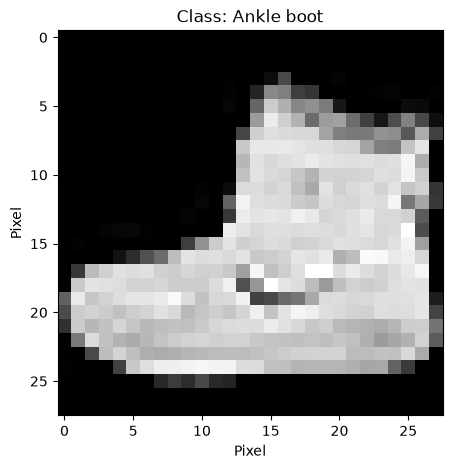

In [7]:
# 5. Visualize a sample image from the dataset
# The image is displayed in grayscale.
# The corresponding class label is also displayed.

plt.figure(figsize=(5, 5))

plt.imshow(train_images[0], cmap="gray")
plt.title("Class: " + class_names[train_labels[0]])
plt.xlabel("Pixel")
plt.ylabel("Pixel")
plt.show()

## Visualize Multiple Images

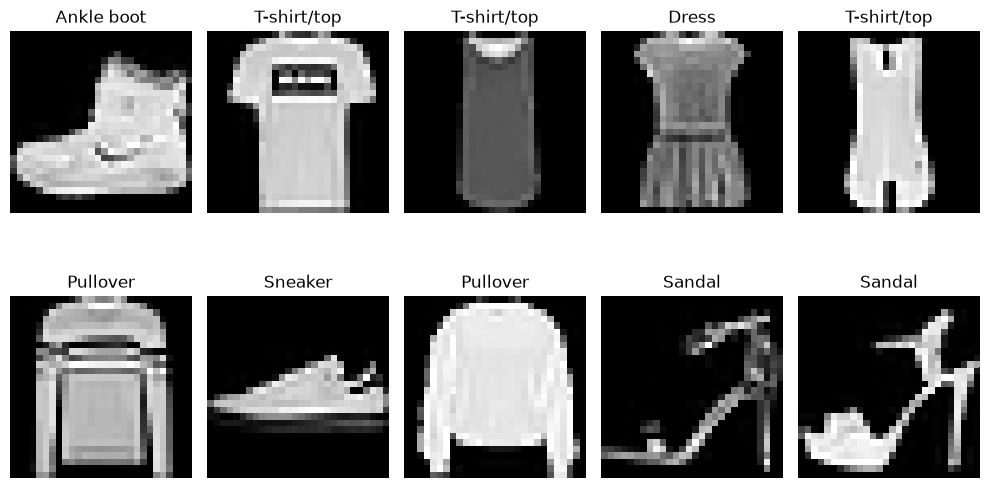

In [8]:
# 6. Display multiple sample images
# This helps us understand the different categories present in the dataset.

plt.figure(figsize=(10, 6))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(train_images[i], cmap="gray")
    plt.title(class_names[train_labels[i]])
    plt.axis("off")

plt.tight_layout()
plt.show()

## Dataset Split

In [9]:
# 7. Dataset split
# The original Fashion-MNIST dataset already provides training and testing data.
# Training dataset contains 60,000 images.
# Testing dataset contains 10,000 images.
#
# We use the training dataset to train the model
# and the testing dataset to evaluate the final performance.

print("Training dataset size:", len(train_images))
print("Testing dataset size:", len(test_images))

print("Training percentage:", len(train_images) / (len(train_images) + len(test_images)) * 100, "%")
print("Testing percentage:", len(test_images) / (len(train_images) + len(test_images)) * 100, "%")

Training dataset size: 60000
Testing dataset size: 10000
Training percentage: 85.71428571428571 %
Testing percentage: 14.285714285714285 %


## Build the Keras Model

In [10]:
# 8. Build the neural network using Keras
# Flatten converts each 28x28 image into a one-dimensional array.
# Dense layers are fully connected neural network layers.
# ReLU is used as the activation function in the hidden layer.
# Softmax is used in the output layer for 10-class classification.

model = keras.Sequential([
    keras.layers.Flatten(input_shape=(28, 28)),
    keras.layers.Dense(128, activation="relu"),
    keras.layers.Dense(10, activation="softmax")
])

model.summary()

C:\Users\Aksha\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

## Compile the Model

In [11]:
# 9. Compile the model
# Adam is used as the optimizer.
# Sparse categorical crossentropy is used as the loss function
# because the labels are integer class values.
# Accuracy is used as the evaluation metric.

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully.")

Model compiled successfully.


## Training

In [12]:
# 10. Train the model
# The model learns patterns from the training images and their labels.
# Epochs specify how many times the complete training dataset is processed.
# We use 5 epochs for demonstration.

history = model.fit(
    train_images,
    train_labels,
    epochs=5,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.8203 - loss: 0.5164 - val_accuracy: 0.8488 - val_loss: 0.4170
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8613 - loss: 0.3860 - val_accuracy: 0.8599 - val_loss: 0.3854
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8734 - loss: 0.3472 - val_accuracy: 0.8707 - val_loss: 0.3595
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8825 - loss: 0.3224 - val_accuracy: 0.8798 - val_loss: 0.3400
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8889 - loss: 0.3021 - val_accuracy: 0.8767 - val_loss: 0.3468


## Evaluation

In [13]:
# 11. Evaluate the trained model
# The test dataset contains images that were not used during training.
# This allows us to measure how well the model performs on unseen data.

test_loss, test_accuracy = model.evaluate(
    test_images,
    test_labels
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8670 - loss: 0.3743
Test Loss: 0.37428605556488037
Test Accuracy: 0.8669999837875366


## Plot Training Accuracy

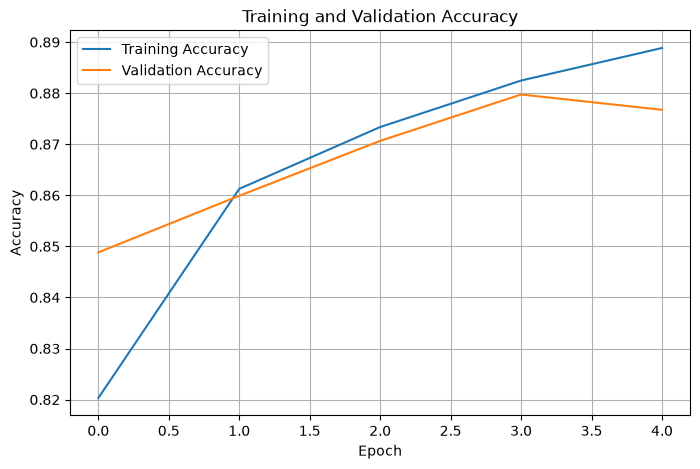

In [14]:
# 12. Visualize training and validation accuracy
# This graph shows how the model's accuracy changes over the epochs.

plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()

plt.show()

## Plot Loss

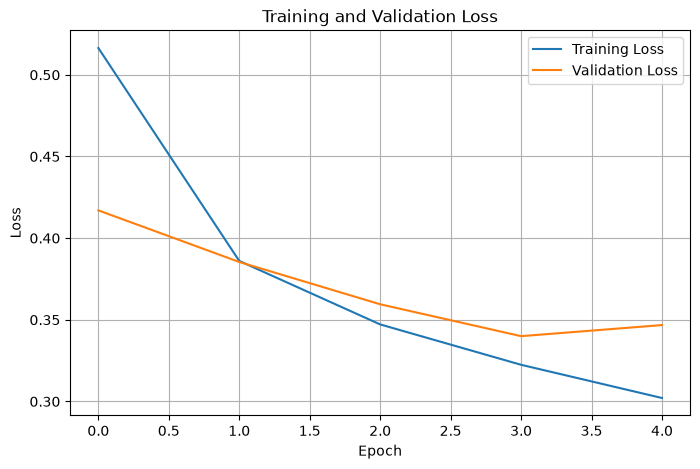

In [15]:
# 13. Visualize training and validation loss
# Loss indicates how far the model's predictions are from the actual labels.
# Lower loss generally indicates better model performance.

plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid()

plt.show()

## Predict a Sample Image

In [17]:
# 14. Predict the class of a sample image
# The trained model predicts the class probabilities for the selected image.
# The class with the highest probability is selected as the prediction.

import numpy as np
predictions = model.predict(test_images)

predicted_label = np.argmax(predictions[0])

print("Predicted class:", class_names[predicted_label])
print("Actual class:", class_names[test_labels[0]])

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Predicted class: Ankle boot
Actual class: Ankle boot
